**Data Extraction**

In [1]:
# Connect to the OpenWeatherMap API and retrieve weather data for a single city.
import requests

API_KEY = "cdd147369a34ad62fb59ee1d274819d4"

url = f"https://api.openweathermap.org/data/2.5/weather?q=Port Harcourt&appid={API_KEY}&units=metric"

response = requests.get(url)

data = response.json()

print(data)

{'coord': {'lon': 7.0134, 'lat': 4.7774}, 'weather': [{'id': 804, 'main': 'Clouds', 'description': 'overcast clouds', 'icon': '04d'}], 'base': 'stations', 'main': {'temp': 24.77, 'feels_like': 25.52, 'temp_min': 24.77, 'temp_max': 24.77, 'pressure': 1013, 'humidity': 85, 'sea_level': 1013, 'grnd_level': 1011}, 'visibility': 10000, 'wind': {'speed': 3.16, 'deg': 228, 'gust': 4.43}, 'clouds': {'all': 100}, 'dt': 1782138830, 'sys': {'country': 'NG', 'sunrise': 1782105715, 'sunset': 1782150348}, 'timezone': 3600, 'id': 2324774, 'name': 'Port Harcourt', 'cod': 200}


In [2]:
# Display the API response in a structured JSON format for easier exploration.
import json

print(json.dumps(data, indent=4))

{
    "coord": {
        "lon": 7.0134,
        "lat": 4.7774
    },
    "weather": [
        {
            "id": 804,
            "main": "Clouds",
            "description": "overcast clouds",
            "icon": "04d"
        }
    ],
    "base": "stations",
    "main": {
        "temp": 24.77,
        "feels_like": 25.52,
        "temp_min": 24.77,
        "temp_max": 24.77,
        "pressure": 1013,
        "humidity": 85,
        "sea_level": 1013,
        "grnd_level": 1011
    },
    "visibility": 10000,
    "wind": {
        "speed": 3.16,
        "deg": 228,
        "gust": 4.43
    },
    "clouds": {
        "all": 100
    },
    "dt": 1782138830,
    "sys": {
        "country": "NG",
        "sunrise": 1782105715,
        "sunset": 1782150348
    },
    "timezone": 3600,
    "id": 2324774,
    "name": "Port Harcourt",
    "cod": 200
}


In [3]:
# Display all top-level fields available in the API response.
print(data.keys())

dict_keys(['coord', 'weather', 'base', 'main', 'visibility', 'wind', 'clouds', 'dt', 'sys', 'timezone', 'id', 'name', 'cod'])


In [4]:
# Display all weather measurement fields contained within the main section.
print(data["main"])

{'temp': 24.77, 'feels_like': 25.52, 'temp_min': 24.77, 'temp_max': 24.77, 'pressure': 1013, 'humidity': 85, 'sea_level': 1013, 'grnd_level': 1011}


In [5]:
# Display all wind-related fields available in the API response.
print(data["wind"])

{'speed': 3.16, 'deg': 228, 'gust': 4.43}


In [6]:
# Display country and sunrise/sunset information.
print(data["sys"])

{'country': 'NG', 'sunrise': 1782105715, 'sunset': 1782150348}


In [7]:
# Extract selected weather metrics for multiple cities and store them in a list of dictionaries.
import requests
import pandas as pd

API_KEY = "cdd147369a34ad62fb59ee1d274819d4"

cities = ["Port Harcourt", "Lagos", "Abuja", "Ilesa", "Uyo"]

weather_data = []

for city in cities:

    url = f"https://api.openweathermap.org/data/2.5/weather?q={city}&appid={API_KEY}&units=metric"

    response = requests.get(url)

    data = response.json()

    weather_data.append({
        "City": data["name"],
        "Country": data["sys"]["country"],
        "Temperature_C": data["main"]["temp"],
        "Feels_Like_C": data["main"]["feels_like"],
        "Humidity": data["main"]["humidity"],
        "Pressure": data["main"]["pressure"],
        "Visibility": data["visibility"],
        "WindSpeed_mps": data["wind"]["speed"],
        "WindDirection": data["wind"]["deg"],
        "WindGust": data["wind"].get("gust"),
        "CloudCover": data["clouds"]["all"],
        "WeatherCondition": data["weather"][0]["description"],
        "Sunrise": data["sys"]["sunrise"],
        "Sunset": data["sys"]["sunset"],
        "DateTime": data["dt"]
    })

print(weather_data)

[{'City': 'Port Harcourt', 'Country': 'NG', 'Temperature_C': 24.77, 'Feels_Like_C': 25.52, 'Humidity': 85, 'Pressure': 1013, 'Visibility': 10000, 'WindSpeed_mps': 3.16, 'WindDirection': 228, 'WindGust': 4.43, 'CloudCover': 100, 'WeatherCondition': 'overcast clouds', 'Sunrise': 1782105715, 'Sunset': 1782150348, 'DateTime': 1782138830}, {'City': 'Lagos', 'Country': 'NG', 'Temperature_C': 26.09, 'Feels_Like_C': 26.09, 'Humidity': 82, 'Pressure': 1014, 'Visibility': 10000, 'WindSpeed_mps': 2.93, 'WindDirection': 192, 'WindGust': 4.46, 'CloudCover': 100, 'WeatherCondition': 'overcast clouds', 'Sunrise': 1782106308, 'Sunset': 1782151322, 'DateTime': 1782138601}, {'City': 'Abuja', 'Country': 'NG', 'Temperature_C': 28.26, 'Feels_Like_C': 30.61, 'Humidity': 66, 'Pressure': 1012, 'Visibility': 10000, 'WindSpeed_mps': 2.29, 'WindDirection': 262, 'WindGust': 2.01, 'CloudCover': 97, 'WeatherCondition': 'light rain', 'Sunrise': 1782105146, 'Sunset': 1782150689, 'DateTime': 1782138573}, {'City': 'Ile

**Transform**

In [8]:
# Convert the extracted weather data into a pandas DataFrame and display the first few records.
df = pd.DataFrame(weather_data)

print(df.head())

            City Country  Temperature_C  Feels_Like_C  Humidity  Pressure  \
0  Port Harcourt      NG          24.77         25.52        85      1013   
1          Lagos      NG          26.09         26.09        82      1014   
2          Abuja      NG          28.26         30.61        66      1012   
3          Ilesa      NG          24.12         24.75        83      1013   
4            Uyo      NG          26.15         26.15        82      1013   

   Visibility  WindSpeed_mps  WindDirection  WindGust  CloudCover  \
0       10000           3.16            228      4.43         100   
1       10000           2.93            192      4.46         100   
2       10000           2.29            262      2.01          97   
3       10000           2.33            191      3.93          99   
4       10000           2.74            215      4.07          98   

  WeatherCondition     Sunrise      Sunset    DateTime  
0  overcast clouds  1782105715  1782150348  1782138830  
1  overc

In [9]:
# Display dataset information and data types.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   City              5 non-null      str    
 1   Country           5 non-null      str    
 2   Temperature_C     5 non-null      float64
 3   Feels_Like_C      5 non-null      float64
 4   Humidity          5 non-null      int64  
 5   Pressure          5 non-null      int64  
 6   Visibility        5 non-null      int64  
 7   WindSpeed_mps     5 non-null      float64
 8   WindDirection     5 non-null      int64  
 9   WindGust          5 non-null      float64
 10  CloudCover        5 non-null      int64  
 11  WeatherCondition  5 non-null      str    
 12  Sunrise           5 non-null      int64  
 13  Sunset            5 non-null      int64  
 14  DateTime          5 non-null      int64  
dtypes: float64(4), int64(8), str(3)
memory usage: 732.0 bytes
None


In [10]:
# Check for missing values in each column.
print(df.isnull().sum())

City                0
Country             0
Temperature_C       0
Feels_Like_C        0
Humidity            0
Pressure            0
Visibility          0
WindSpeed_mps       0
WindDirection       0
WindGust            0
CloudCover          0
WeatherCondition    0
Sunrise             0
Sunset              0
DateTime            0
dtype: int64


In [11]:
# Convert Unix timestamps into readable datetime format.
df["Sunrise"] = pd.to_datetime(df["Sunrise"], unit="s")
df["Sunset"] = pd.to_datetime(df["Sunset"], unit="s")
df["DateTime"] = pd.to_datetime(df["DateTime"], unit="s")

print(df.head())

            City Country  Temperature_C  Feels_Like_C  Humidity  Pressure  \
0  Port Harcourt      NG          24.77         25.52        85      1013   
1          Lagos      NG          26.09         26.09        82      1014   
2          Abuja      NG          28.26         30.61        66      1012   
3          Ilesa      NG          24.12         24.75        83      1013   
4            Uyo      NG          26.15         26.15        82      1013   

   Visibility  WindSpeed_mps  WindDirection  WindGust  CloudCover  \
0       10000           3.16            228      4.43         100   
1       10000           2.93            192      4.46         100   
2       10000           2.29            262      2.01          97   
3       10000           2.33            191      3.93          99   
4       10000           2.74            215      4.07          98   

  WeatherCondition             Sunrise              Sunset            DateTime  
0  overcast clouds 2026-06-22 05:21:55 20

In [12]:
# Verify that datetime conversion was successful.
print(df.info())

<class 'pandas.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype        
---  ------            --------------  -----        
 0   City              5 non-null      str          
 1   Country           5 non-null      str          
 2   Temperature_C     5 non-null      float64      
 3   Feels_Like_C      5 non-null      float64      
 4   Humidity          5 non-null      int64        
 5   Pressure          5 non-null      int64        
 6   Visibility        5 non-null      int64        
 7   WindSpeed_mps     5 non-null      float64      
 8   WindDirection     5 non-null      int64        
 9   WindGust          5 non-null      float64      
 10  CloudCover        5 non-null      int64        
 11  WeatherCondition  5 non-null      str          
 12  Sunrise           5 non-null      datetime64[s]
 13  Sunset            5 non-null      datetime64[s]
 14  DateTime          5 non-null      datetime64[s]
dtypes: d

In [13]:
# Calculate the duration between sunrise and sunset.
df["DayLength_Hours"] = (
    df["Sunset"] - df["Sunrise"]
).dt.total_seconds() / 3600

In [14]:
# Calculate the difference between actual and feels-like temperature.
df["Temp_Difference"] = (
    df["Feels_Like_C"] - df["Temperature_C"]
)

In [15]:
# Display the transformed dataset.
print(df.head())

            City Country  Temperature_C  Feels_Like_C  Humidity  Pressure  \
0  Port Harcourt      NG          24.77         25.52        85      1013   
1          Lagos      NG          26.09         26.09        82      1014   
2          Abuja      NG          28.26         30.61        66      1012   
3          Ilesa      NG          24.12         24.75        83      1013   
4            Uyo      NG          26.15         26.15        82      1013   

   Visibility  WindSpeed_mps  WindDirection  WindGust  CloudCover  \
0       10000           3.16            228      4.43         100   
1       10000           2.93            192      4.46         100   
2       10000           2.29            262      2.01          97   
3       10000           2.33            191      3.93          99   
4       10000           2.74            215      4.07          98   

  WeatherCondition             Sunrise              Sunset  \
0  overcast clouds 2026-06-22 05:21:55 2026-06-22 17:45:48  

**Load Data**

In [16]:
# Save the transformed weather dataset as a CSV file.
df.to_csv(
    "weather_data_transformed.csv",
    index=False
)

print("Dataset saved successfully.")

Dataset saved successfully.


In [17]:
# Display the transformed weather dataset
df.head()

,City,Country,Temperature_C,Feels_Like_C,Humidity,Pressure,Visibility,WindSpeed_mps,WindDirection,WindGust,CloudCover,WeatherCondition,Sunrise,Sunset,DateTime,DayLength_Hours,Temp_Difference
0,Port Harcourt,NG,24.77,25.52,85,1013,10000,3.16,228,4.43,100,overcast clouds,2026-06-22 05:21:55,2026-06-22 17:45:48,2026-06-22 14:33:50,12.398056,0.75
1,Lagos,NG,26.09,26.09,82,1014,10000,2.93,192,4.46,100,overcast clouds,2026-06-22 05:31:48,2026-06-22 18:02:02,2026-06-22 14:30:01,12.503889,0.00
2,Abuja,NG,28.26,30.61,66,1012,10000,2.29,262,2.01,97,light rain,2026-06-22 05:12:26,2026-06-22 17:51:29,2026-06-22 14:29:33,12.650833,2.35
3,Ilesa,NG,24.12,24.75,83,1013,10000,2.33,191,3.93,99,overcast clouds,2026-06-22 05:26:02,2026-06-22 17:59:56,2026-06-22 14:30:25,12.565000,0.63
4,Uyo,NG,26.15,26.15,82,1013,10000,2.74,215,4.07,98,overcast clouds,2026-06-22 05:17:49,2026-06-22 17:42:36,2026-06-22 14:33:59,12.413056,0.00


**Basic Analysis**

In [18]:
# Find the city with the highest recorded temperature
highest_temp = df.loc[df["Temperature_C"].idxmax()]

print(highest_temp)

City                              Abuja
Country                              NG
Temperature_C                     28.26
Feels_Like_C                      30.61
Humidity                             66
Pressure                           1012
Visibility                        10000
WindSpeed_mps                      2.29
WindDirection                       262
WindGust                           2.01
CloudCover                           97
WeatherCondition             light rain
Sunrise             2026-06-22 05:12:26
Sunset              2026-06-22 17:51:29
DateTime            2026-06-22 14:29:33
DayLength_Hours               12.650833
Temp_Difference                    2.35
Name: 2, dtype: object


In [19]:
# Find the city with the highest humidity level
highest_humidity = df.loc[df["Humidity"].idxmax()]

print(highest_humidity)

City                      Port Harcourt
Country                              NG
Temperature_C                     24.77
Feels_Like_C                      25.52
Humidity                             85
Pressure                           1013
Visibility                        10000
WindSpeed_mps                      3.16
WindDirection                       228
WindGust                           4.43
CloudCover                          100
WeatherCondition        overcast clouds
Sunrise             2026-06-22 05:21:55
Sunset              2026-06-22 17:45:48
DateTime            2026-06-22 14:33:50
DayLength_Hours               12.398056
Temp_Difference                    0.75
Name: 0, dtype: object


In [20]:
# Display weather conditions for all cities
print(df[["City", "WeatherCondition"]])

            City WeatherCondition
0  Port Harcourt  overcast clouds
1          Lagos  overcast clouds
2          Abuja       light rain
3          Ilesa  overcast clouds
4            Uyo  overcast clouds


In [21]:
# Find the city with the highest wind speed
highest_wind = df.loc[df["WindSpeed_mps"].idxmax()]

print(highest_wind)

City                      Port Harcourt
Country                              NG
Temperature_C                     24.77
Feels_Like_C                      25.52
Humidity                             85
Pressure                           1013
Visibility                        10000
WindSpeed_mps                      3.16
WindDirection                       228
WindGust                           4.43
CloudCover                          100
WeatherCondition        overcast clouds
Sunrise             2026-06-22 05:21:55
Sunset              2026-06-22 17:45:48
DateTime            2026-06-22 14:33:50
DayLength_Hours               12.398056
Temp_Difference                    0.75
Name: 0, dtype: object


In [22]:
# Sort cities from highest to lowest temperature
temp_ranking = df.sort_values(by="Temperature_C", ascending=False)

print(temp_ranking[["City", "Temperature_C"]])

            City  Temperature_C
2          Abuja          28.26
4            Uyo          26.15
1          Lagos          26.09
0  Port Harcourt          24.77
3          Ilesa          24.12


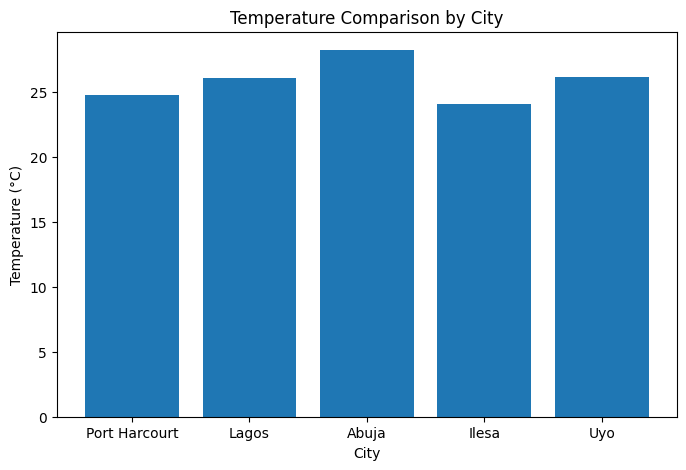

In [23]:
# Create a bar chart comparing temperatures across cities
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.bar(df["City"], df["Temperature_C"])

plt.title("Temperature Comparison by City")
plt.xlabel("City")
plt.ylabel("Temperature (°C)")

plt.show()

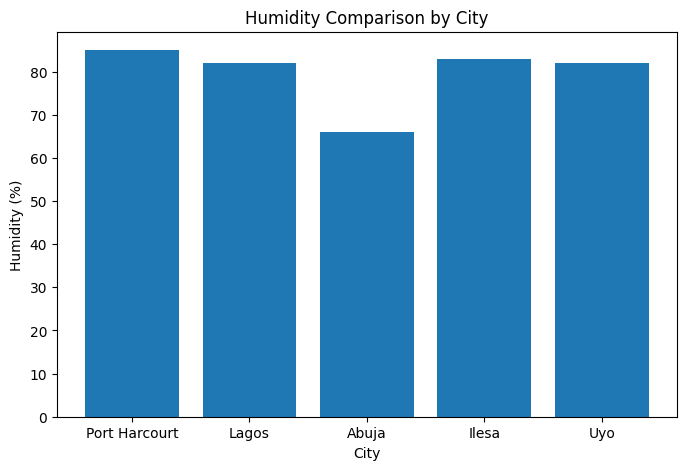

In [24]:
# Create a bar chart comparing humidity levels across cities
plt.figure(figsize=(8,5))

plt.bar(df["City"], df["Humidity"])

plt.title("Humidity Comparison by City")
plt.xlabel("City")
plt.ylabel("Humidity (%)")

plt.show()

In [25]:
# Find the city with the longest daylight duration
longest_day = df.loc[
    df["DayLength_Hours"].idxmax()
]

print(longest_day)

City                              Abuja
Country                              NG
Temperature_C                     28.26
Feels_Like_C                      30.61
Humidity                             66
Pressure                           1012
Visibility                        10000
WindSpeed_mps                      2.29
WindDirection                       262
WindGust                           2.01
CloudCover                           97
WeatherCondition             light rain
Sunrise             2026-06-22 05:12:26
Sunset              2026-06-22 17:51:29
DateTime            2026-06-22 14:29:33
DayLength_Hours               12.650833
Temp_Difference                    2.35
Name: 2, dtype: object


In [26]:
# Find the city with the highest temperature difference
highest_feels_like = df.loc[
    df["Temp_Difference"].idxmax()
]

print(highest_feels_like)

City                              Abuja
Country                              NG
Temperature_C                     28.26
Feels_Like_C                      30.61
Humidity                             66
Pressure                           1012
Visibility                        10000
WindSpeed_mps                      2.29
WindDirection                       262
WindGust                           2.01
CloudCover                           97
WeatherCondition             light rain
Sunrise             2026-06-22 05:12:26
Sunset              2026-06-22 17:51:29
DateTime            2026-06-22 14:29:33
DayLength_Hours               12.650833
Temp_Difference                    2.35
Name: 2, dtype: object


**Insights**

1. Abuja recorded the highest temperature at 32.35°C, making it the warmest city in the dataset.
2. Uyo recorded the highest humidity level at 79%, indicating the most humid atmospheric conditions among the selected cities.
3. All five cities recorded overcast cloud conditions, suggesting similar cloud coverage patterns at the time of data collection.
4. Lagos recorded the highest wind speed at 4.06 m/s and the highest wind gust at 4.40 m/s, making it the windiest city in the dataset.
5. Temperature rankings showed a clear spread across the cities, with temperatures ranging from 26.78°C in Uyo to 32.35°C in Abuja.
6. Abuja recorded the longest daylight duration at approximately 12.65 hours, while Uyo recorded the shortest at approximately 12.41 hours.
7. The feels-like temperature was higher than the actual temperature in every city, indicating that weather conditions felt warmer than the recorded air temperature.
8. Lagos recorded the highest temperature difference at 3.81°C, meaning it felt substantially warmer than its measured temperature of 29.23°C.

In [27]:
# Export cleaned dataset to a CSV file

df.to_csv(
    r"C:\Users\adero\Downloads\cleaned_weather_data.csv",
    index=False
)

print("Dataset exported successfully.")

Dataset exported successfully.
